# Mini-batch sampling for PINN training -- harder PDE (Numerical Example #12)

This notebook is a direct port of `ex11` to a **harder PDE** that exhibits
sharp, spatially-localized residuals -- precisely the regime where
spatial-stratification is expected to widen its advantage over naive
mini-batches.

We solve a 1D **advection-dominated advection-diffusion** problem:
$$u_t + c\,u_x - \mu\,u_{xx} = s(x,t), \qquad (x,t) \in [-1,1]\times[0,1],$$
with $c = 1$, $\mu = 0.01$ (Péclet number $\mathrm{Pe} = cL/\mu = 200$).
The manufactured solution is a Gaussian pulse advecting from $x=-0.5$ to $x=+0.5$:
$$u_\star(x,t) = \exp\!\bigl(-50\,(x + 0.5 - c\,t)^2\bigr),$$
which produces a residual that is sharply concentrated at the moving pulse.
Boundary and initial conditions are non-homogeneous (taken from $u_\star$).

The architecture, optimizer, candidate pool, mini-batch strategies, and the
two experiments (5-strategy comparison at $|\mathcal{I}_k|=16$; batch-size
sweep) are unchanged from `ex11`, so any difference in the strategy
ordering is attributable purely to the harder PDE.

In [1]:
import copy, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
torch.set_default_dtype(torch.float64)

PI = math.pi
C_ADV = 1.0
MU    = 0.01

## 1. Problem setup

Manufactured Gaussian pulse $u_\star(x,t) = \exp(-50(x+0.5-ct)^2)$ advects
across the domain over $t \in [0,1]$, staying $\sim 0.5$ away from the
boundaries. Source term cancels the advection part, leaving only
$s = -\mu\,u_{xx}$.

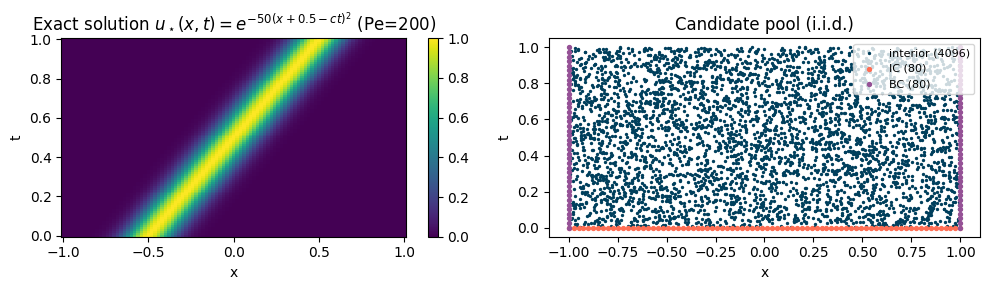

In [2]:
def u_exact(xt):
    """Manufactured exact solution: Gaussian pulse advecting at speed c."""
    x, t = xt[..., 0:1], xt[..., 1:2]
    arg = x + 0.5 - C_ADV * t
    return torch.exp(-50.0 * arg ** 2)

def src(xt):
    """Source term so u_* satisfies u_t + c u_x - mu u_xx = src."""
    x, t = xt[..., 0:1], xt[..., 1:2]
    arg = x + 0.5 - C_ADV * t
    u = torch.exp(-50.0 * arg ** 2)
    # u_t + c u_x = 0 by construction (u depends only on x - c t).
    # u_xx = (10000 arg^2 - 100) * u, hence -mu u_xx = -mu(10000 arg^2 - 100) u
    return -MU * (10000.0 * arg ** 2 - 100.0) * u

M_PDE = 4096
M_IC  = 80
M_BC  = 80

def make_pool(seed=1, m_pde=M_PDE):
    """Build the fixed candidate pool: i.i.d. uniform interior, equispaced IC/BC."""
    g = torch.Generator().manual_seed(seed)
    xt_pde = torch.empty(m_pde, 2)
    xt_pde[:, 0] = torch.rand(m_pde, generator=g) * 2.0 - 1.0
    xt_pde[:, 1] = torch.rand(m_pde, generator=g)
    xt_ic = torch.zeros(M_IC, 2)
    xt_ic[:, 0] = torch.linspace(-1, 1, M_IC)
    half = M_BC // 2
    xt_bc = torch.zeros(M_BC, 2)
    xt_bc[:half, 0] = -1.0; xt_bc[:half, 1] = torch.linspace(0, 1, half)
    xt_bc[half:, 0] =  1.0; xt_bc[half:, 1] = torch.linspace(0, 1, M_BC - half)
    return xt_pde, xt_ic, xt_bc

# Test grid for L2 error.
nx, nt = 101, 101
xx = torch.linspace(-1, 1, nx); tt = torch.linspace(0, 1, nt)
X_TEST, T_TEST = torch.meshgrid(xx, tt, indexing='xy')
TEST_XT = torch.stack([X_TEST.reshape(-1), T_TEST.reshape(-1)], dim=1)
TEST_U  = u_exact(TEST_XT)

xt_pde_pool, xt_ic_pool, xt_bc_pool = make_pool(seed=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.0))
im = axes[0].pcolormesh(X_TEST.numpy(), T_TEST.numpy(),
                        TEST_U.reshape(nt, nx).numpy(), shading='auto', cmap='viridis')
axes[0].set_xlabel('x'); axes[0].set_ylabel('t')
axes[0].set_title(r'Exact solution $u_\star(x,t) = e^{-50(x + 0.5 - ct)^2}$ (Pe=200)')
fig.colorbar(im, ax=axes[0])
axes[1].scatter(xt_pde_pool[:, 0], xt_pde_pool[:, 1], s=2, color='#003F5C', label=f'interior ({M_PDE})')
axes[1].scatter(xt_ic_pool[:,  0], xt_ic_pool[:,  1], s=8, color='#FF6E54', label=f'IC ({M_IC})')
axes[1].scatter(xt_bc_pool[:,  0], xt_bc_pool[:,  1], s=8, color='#955196', label=f'BC ({M_BC})')
axes[1].set_xlabel('x'); axes[1].set_ylabel('t'); axes[1].set_title('Candidate pool (i.i.d.)')
axes[1].legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

## 2. PINN model and loss

Same MLP and three-term equal-weight loss as `ex11`. The only changes are:
- `residual` now computes $u_t + c\,u_x - \mu\,u_{xx} - s$ (advection-diffusion).
- IC and BC losses use the exact $u_\star$ as target (non-homogeneous).

In [3]:
class PINN(nn.Module):
    def __init__(self, depth=4, width=32):
        super().__init__()
        layers = [nn.Linear(2, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, xt):
        return self.net(xt)

def residual(model, xt):
    """PDE residual r = u_t + c u_x - mu u_xx - src, autograd through the network."""
    g = xt.clone().detach().requires_grad_(True)
    u = model(g)
    grads = torch.autograd.grad(u, g, torch.ones_like(u), create_graph=True)[0]
    ux, ut = grads[..., 0:1], grads[..., 1:2]
    uxx = torch.autograd.grad(ux, g, torch.ones_like(ux), create_graph=True)[0][..., 0:1]
    return ut + C_ADV * ux - MU * uxx - src(g)

def batch_loss(model, b_pde, b_ic, b_bc):
    """Three-term equal-weight (1, 1, 1) PINN loss with non-homogeneous IC/BC."""
    L = 0.0
    if len(b_pde):
        L = L + (residual(model, b_pde) ** 2).mean()
    if len(b_ic):
        u_ic_pred = model(b_ic).squeeze(-1)
        u_ic_true = u_exact(b_ic).squeeze(-1)
        L = L + ((u_ic_pred - u_ic_true) ** 2).mean()
    if len(b_bc):
        u_bc_pred = model(b_bc).squeeze(-1)
        u_bc_true = u_exact(b_bc).squeeze(-1)
        L = L + ((u_bc_pred - u_bc_true) ** 2).mean()
    return L

def l2_rel(model):
    with torch.no_grad():
        u_pred = model(TEST_XT)
    return float(torch.sqrt(((u_pred - TEST_U) ** 2).sum() / (TEST_U ** 2).sum()))

def full_pool_loss(model, xt_pde, xt_ic, xt_bc):
    with torch.no_grad():
        L_ic = ((model(xt_ic).squeeze(-1) - u_exact(xt_ic).squeeze(-1)) ** 2).mean()
        L_bc = ((model(xt_bc).squeeze(-1) - u_exact(xt_bc).squeeze(-1)) ** 2).mean()
    L_pde = (residual(model, xt_pde) ** 2).mean()
    return float((L_pde + L_ic + L_bc).detach())

## 3. Mini-batch strategies

Identical to `ex11` -- five strategies layering bias correction, time
curriculum, and spatial-cell stratification.

In [4]:
POOL_FRAC  = (M_PDE/(M_PDE + M_IC + M_BC),
              M_IC /(M_PDE + M_IC + M_BC),
              M_BC /(M_PDE + M_IC + M_BC))
STRAT_FRAC = (1/3, 1/3, 1/3)

def _split(B, frac):
    bs_pde = round(B * frac[0])
    bs_ic  = round(B * frac[1])
    bs_bc  = B - bs_pde - bs_ic
    return bs_pde, bs_ic, bs_bc

SPATIAL_KX, SPATIAL_KT = 8, 8
SPATIAL_K  = SPATIAL_KX * SPATIAL_KT

def _cell_id(xt, kx=SPATIAL_KX, kt=SPATIAL_KT):
    x, t = xt[:, 0], xt[:, 1]
    ix = torch.clamp(((x + 1) / 2 * kx).long(), 0, kx - 1)
    it = torch.clamp((t * kt).long(), 0, kt - 1)
    return ix * kt + it

class SpatialStratifier:
    def __init__(self, xt_pool):
        self.xt = xt_pool
        cells = _cell_id(xt_pool)
        self.cell_idx = [(cells == c).nonzero(as_tuple=True)[0] for c in range(SPATIAL_K)]
        self.t_pool = xt_pool[:, 1]
    def sample(self, n_take, t_max=None):
        if t_max is None:
            cell_idx = self.cell_idx
        else:
            mask = (self.t_pool <= t_max)
            cell_idx = [ci[mask[ci]] for ci in self.cell_idx]
        occupied = [c for c in range(SPATIAL_K) if len(cell_idx[c]) > 0]
        if not occupied:
            return torch.tensor([], dtype=torch.long)
        chosen = []
        if n_take <= len(occupied):
            pick = torch.randperm(len(occupied))[:n_take]
            for j in pick:
                c = occupied[j.item()]
                ci = cell_idx[c]
                chosen.append(ci[torch.randint(len(ci), (1,))].item())
        else:
            per = n_take // len(occupied)
            rem = n_take - per * len(occupied)
            for jj, c in enumerate(occupied):
                n = per + (1 if jj < rem else 0)
                ci = cell_idx[c]
                if n <= len(ci):
                    pk = ci[torch.randperm(len(ci))[:n]]
                else:
                    pk = ci[torch.randint(len(ci), (n,))]
                chosen.extend(pk.tolist())
        return torch.tensor(chosen, dtype=torch.long)

_STRATIFIER_CACHE = {}
def stratifier_for(xt_pool):
    k = id(xt_pool)
    if k not in _STRATIFIER_CACHE:
        _STRATIFIER_CACHE[k] = SpatialStratifier(xt_pool)
    return _STRATIFIER_CACHE[k]

T_CUR_MIN, T_CUR_WARM = 0.05, 0.3
def t_cur(k, K, t_min=T_CUR_MIN, t_warm=T_CUR_WARM):
    return t_min + (1.0 - t_min) * min(1.0, k / max(1, t_warm * K))

def uniform_batch(xt_pde, xt_ic, xt_bc, B, k=None, K=None):
    bs_pde, bs_ic, bs_bc = _split(B, POOL_FRAC)
    return (xt_pde[torch.randperm(len(xt_pde))[:bs_pde]],
            xt_ic[torch.randperm(len(xt_ic))[:bs_ic]],
            xt_bc[torch.randperm(len(xt_bc))[:bs_bc]])

def stratified_batch(xt_pde, xt_ic, xt_bc, B, k=None, K=None):
    bs_pde, bs_ic, bs_bc = _split(B, STRAT_FRAC)
    return (xt_pde[torch.randperm(len(xt_pde))[:bs_pde]],
            xt_ic[torch.randperm(len(xt_ic))[:bs_ic]],
            xt_bc[torch.randperm(len(xt_bc))[:bs_bc]])

def spatial_batch(xt_pde, xt_ic, xt_bc, B, k=None, K=None):
    bs_pde, bs_ic, bs_bc = _split(B, STRAT_FRAC)
    idx_pde = stratifier_for(xt_pde).sample(bs_pde)
    return (xt_pde[idx_pde],
            xt_ic[torch.randperm(len(xt_ic))[:bs_ic]],
            xt_bc[torch.randperm(len(xt_bc))[:bs_bc]])

def causal_batch(xt_pde, xt_ic, xt_bc, B, k, K):
    bs_pde, bs_ic, bs_bc = _split(B, STRAT_FRAC)
    Tk = t_cur(k, K)
    mask_pde = (xt_pde[:, 1] <= Tk).nonzero(as_tuple=True)[0]
    mask_bc  = (xt_bc[:, 1] <= Tk).nonzero(as_tuple=True)[0]
    if len(mask_pde) < bs_pde:
        idx_pde = mask_pde[torch.randint(len(mask_pde), (bs_pde,))]
    else:
        idx_pde = mask_pde[torch.randperm(len(mask_pde))[:bs_pde]]
    idx_ic = torch.randperm(len(xt_ic))[:bs_ic]
    if len(mask_bc) < bs_bc:
        idx_bc = mask_bc[torch.randint(len(mask_bc), (bs_bc,))]
    else:
        idx_bc = mask_bc[torch.randperm(len(mask_bc))[:bs_bc]]
    return xt_pde[idx_pde], xt_ic[idx_ic], xt_bc[idx_bc]

def all_batch(xt_pde, xt_ic, xt_bc, B, k, K):
    bs_pde, bs_ic, bs_bc = _split(B, STRAT_FRAC)
    Tk = t_cur(k, K)
    idx_pde = stratifier_for(xt_pde).sample(bs_pde, t_max=Tk)
    if len(idx_pde) < bs_pde:
        more = torch.randperm(len(xt_pde))[:bs_pde - len(idx_pde)]
        idx_pde = torch.cat([idx_pde, more])
    mask_bc = (xt_bc[:, 1] <= Tk).nonzero(as_tuple=True)[0]
    if len(mask_bc) < bs_bc:
        idx_bc = mask_bc[torch.randint(len(mask_bc), (bs_bc,))]
    else:
        idx_bc = mask_bc[torch.randperm(len(mask_bc))[:bs_bc]]
    return xt_pde[idx_pde], xt_ic[torch.randperm(len(xt_ic))[:bs_ic]], xt_bc[idx_bc]

SELECTORS = {'uniform': uniform_batch, 'stratified': stratified_batch,
             'spatial': spatial_batch, 'causal': causal_batch, 'all': all_batch}
LABELS = {'uniform': 'Uniform', 'stratified': 'Stratified (loss components)',
          'spatial': 'Spatial-stratified', 'causal': 'Causal (loss-strat + time)',
          'all': 'All-combined (loss + spatial + time)'}
COLORS = {'uniform': '#003F5C', 'stratified': '#955196',
          'spatial': '#1F8D60', 'causal': '#FF6E54', 'all': '#A6231D'}

## 4. Training loop

Identical to `ex11`. Adam at $\eta = 10^{-3}$ for $K=15{,}000$ iterations.

In [5]:
ITERS    = 15000
LR       = 1e-3
BATCH    = 16
LOG_EVERY = 500

def train(model, xt_pde, xt_ic, xt_bc, strategy='uniform',
          iters=ITERS, lr=LR, batch_size=BATCH, log_every=LOG_EVERY, seed=0):
    selector = SELECTORS[strategy]
    opt = optim.Adam(model.parameters(), lr=lr)
    history = {'iter': [0], 'l2': [l2_rel(model)],
               'loss': [full_pool_loss(model, xt_pde, xt_ic, xt_bc)]}
    torch.manual_seed(seed)
    for k in range(iters):
        b_pde, b_ic, b_bc = selector(xt_pde, xt_ic, xt_bc, batch_size, k=k, K=iters)
        opt.zero_grad()
        L = batch_loss(model, b_pde, b_ic, b_bc)
        L.backward()
        opt.step()
        if (k + 1) % log_every == 0:
            history['iter'].append(k + 1)
            history['l2'].append(l2_rel(model))
            history['loss'].append(float(L.detach()))
    return {kk: np.array(vv) for kk, vv in history.items()}

def ewma(x, alpha=0.4):
    out = np.empty_like(x, dtype=float)
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = alpha * x[i] + (1 - alpha) * out[i-1]
    return out

## 5. Experiment A -- 5-strategy comparison ($|\mathcal{I}_k|=16$)

# parameters: 3297
  Exp A:     uniform ... 

41.5s, L2_final=2.791e-01, L2_avg5=7.807e-01
  Exp A:  stratified ... 

46.8s, L2_final=1.921e-02, L2_avg5=2.611e-02
  Exp A:      causal ... 

47.5s, L2_final=4.161e-02, L2_avg5=1.977e-02
  Exp A:     spatial ... 

45.2s, L2_final=8.999e-03, L2_avg5=3.312e-02
  Exp A:         all ... 

60.4s, L2_final=7.618e-03, L2_avg5=9.210e-03


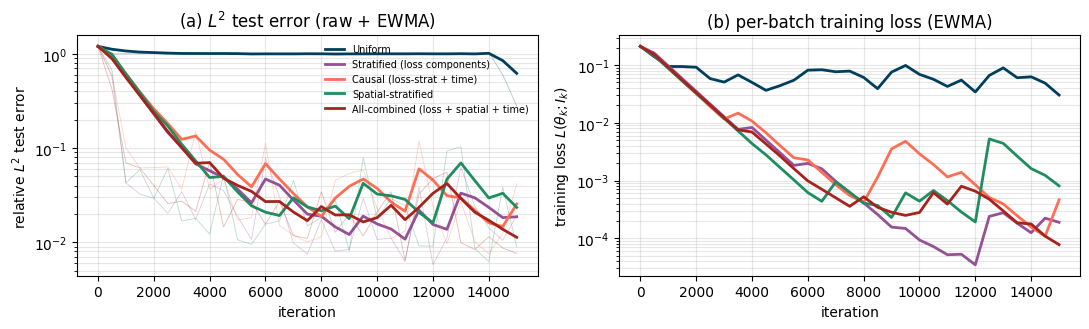

In [6]:
torch.manual_seed(0)
init_model = PINN(depth=4, width=32)
print('# parameters:', sum(p.numel() for p in init_model.parameters()))

xt_pde, xt_ic, xt_bc = make_pool(seed=1, m_pde=4096)

STRATS = ['uniform', 'stratified', 'causal', 'spatial', 'all']
results_A = {}
for strat in STRATS:
    print(f'  Exp A: {strat:>11s} ...', end=' ', flush=True)
    m = copy.deepcopy(init_model)
    t0 = time.time()
    results_A[strat] = train(m, xt_pde, xt_ic, xt_bc, strategy=strat, batch_size=16)
    print(f'{time.time()-t0:.1f}s, L2_final={results_A[strat]["l2"][-1]:.3e}, '
          f'L2_avg5={float(np.mean(results_A[strat]["l2"][-5:])):.3e}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ax = axes[0]
for strat in STRATS:
    h = results_A[strat]
    ax.semilogy(h['iter'], h['l2'],        color=COLORS[strat], lw=0.6, alpha=0.3)
    ax.semilogy(h['iter'], ewma(h['l2']),  color=COLORS[strat], lw=2.0, label=LABELS[strat])
ax.set_xlabel('iteration'); ax.set_ylabel(r'relative $L^2$ test error')
ax.grid(True, which='both', alpha=0.3); ax.legend(frameon=False, fontsize=7, loc='upper right')
ax.set_title(r'(a) $L^2$ test error (raw + EWMA)')

ax = axes[1]
for strat in STRATS:
    h = results_A[strat]
    ax.semilogy(h['iter'], ewma(h['loss']), color=COLORS[strat], lw=2.0, label=LABELS[strat])
ax.set_xlabel('iteration'); ax.set_ylabel(r'training loss $L(\theta_k;I_k)$')
ax.grid(True, which='both', alpha=0.3)
ax.set_title('(b) per-batch training loss (EWMA)')
plt.tight_layout(); plt.show()

import os
RES = '/Users/ak_home/Desktop/tex_files/overleaf/25_opti_chapter/68c1792693900ed5f6cf4853/results/ex12'
os.makedirs(RES, exist_ok=True)
for strat in STRATS:
    h = results_A[strat]
    np.savetxt(f'{RES}/expA_{strat}.csv',
               np.column_stack([h['iter'], h['l2'], h['loss'], ewma(h['l2']), ewma(h['loss'])]),
               header='iter,l2,loss,l2_ewma,loss_ewma',
               delimiter=',', comments='', fmt=['%d', '%.6e', '%.6e', '%.6e', '%.6e'])

## 6. Experiment B -- batch-size sweep

  Exp B:     uniform B=   4 ... 

31.3s, L2_avg5=4.612e+00
  Exp B:     uniform B=   8 ... 

31.7s, L2_avg5=3.014e-01
  Exp B:     uniform B=  16 ... 

38.5s, L2_avg5=7.807e-01
  Exp B:     uniform B=  32 ... 

40.4s, L2_avg5=2.936e-02
  Exp B:     uniform B=  64 ... 

...

61.2s, L2_avg5=9.210e-03
  Exp B:         all B=  32 ... 

64.6s, L2_avg5=1.859e-02
  Exp B:         all B=  64 ... 

70.0s, L2_avg5=9.195e-03
  Exp B:         all B= 128 ... 

75.5s, L2_avg5=3.096e-03
  Exp B:         all B= 256 ... 

92.1s, L2_avg5=5.232e-03


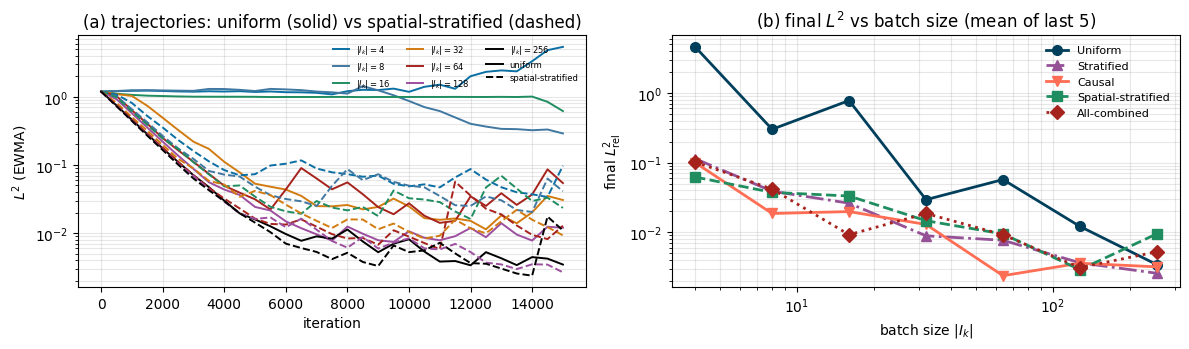


Final L^2 (mean of last 5):
   B     Uniform  Stratified      Causal Spatial-stratified All-combined
   4   4.612e+00   1.138e-01   1.001e-01   6.204e-02   1.023e-01
   8   3.014e-01   3.885e-02   1.858e-02   3.736e-02   4.163e-02
  16   7.807e-01   2.611e-02   1.977e-02   3.312e-02   9.210e-03
  32   2.936e-02   8.875e-03   1.291e-02   1.462e-02   1.859e-02
  64   5.711e-02   7.656e-03   2.371e-03   9.442e-03   9.195e-03
 128   1.211e-02   3.631e-03   3.584e-03   2.892e-03   3.096e-03
 256   3.415e-03   2.568e-03   3.174e-03   9.486e-03   5.232e-03


In [7]:
BATCHES = [4, 8, 16, 32, 64, 128, 256]
STRATS_B = ['uniform', 'stratified', 'causal', 'spatial', 'all']
results_B = {}
for strat in STRATS_B:
    for B in BATCHES:
        print(f'  Exp B: {strat:>11s} B={B:>4d} ...', end=' ', flush=True)
        m = copy.deepcopy(init_model)
        t0 = time.time()
        results_B[(strat, B)] = train(m, xt_pde, xt_ic, xt_bc, strategy=strat,
                                       batch_size=B)
        print(f'{time.time()-t0:.1f}s, L2_avg5={float(np.mean(results_B[(strat, B)]["l2"][-5:])):.3e}')

for (strat, B), h in results_B.items():
    l2_clip = np.minimum(h['l2'], 10.0)
    np.savetxt(f'{RES}/expB_{strat}_B{B}.csv',
               np.column_stack([h['iter'], h['l2'], h['loss'], ewma(l2_clip), ewma(h['loss'])]),
               header='iter,l2,loss,l2_ewma,loss_ewma',
               delimiter=',', comments='', fmt=['%d', '%.6e', '%.6e', '%.6e', '%.6e'])

def final_l2(strat, B):
    return float(np.mean(results_B[(strat, B)]['l2'][-5:]))

with open(f'{RES}/expB_summary.csv', 'w') as f:
    f.write('strategy,batch,L2_final\n')
    for strat in STRATS_B:
        for B in BATCHES:
            f.write(f'{strat},{B},{final_l2(strat, B):.6e}\n')

for strat in STRATS_B:
    rows = [(B, final_l2(strat, B)) for B in BATCHES]
    np.savetxt(f'{RES}/expB_finals_{strat}.csv',
               np.array(rows),
               header='batch,l2_final',
               delimiter=',', comments='', fmt=['%d', '%.6e'])

COLORS_B = {4: '#0B6FA4', 8: '#4078A1', 16: '#1F8D60',
            32: '#D27B11', 64: '#A6231D', 128: '#9D4E9F', 256: '#000000'}
LS = {'uniform': '-', 'stratified': '-.', 'causal': '-', 'spatial': '--', 'all': ':'}
MARKERS = {'uniform': 'o', 'stratified': '^', 'causal': 'v', 'spatial': 's', 'all': 'D'}

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
ax = axes[0]
for strat in ['uniform', 'spatial']:
    for B in BATCHES:
        h = results_B[(strat, B)]
        y = np.clip(ewma(h['l2']), None, 10)
        ax.semilogy(h['iter'], y, color=COLORS_B[B], lw=1.4, ls=LS[strat])
for B in BATCHES:
    ax.semilogy([], [], color=COLORS_B[B], lw=1.4, label=f'$|I_k|={B}$')
ax.semilogy([], [], color='black', lw=1.4, ls='-',  label='uniform')
ax.semilogy([], [], color='black', lw=1.4, ls='--', label='spatial-stratified')
ax.set_xlabel('iteration'); ax.set_ylabel(r'$L^2$ (EWMA)')
ax.grid(True, which='both', alpha=0.3)
ax.legend(frameon=False, fontsize=6, ncol=3, loc='upper right')
ax.set_title('(a) trajectories: uniform (solid) vs spatial-stratified (dashed)')

ax = axes[1]
for strat in STRATS_B:
    finals = [final_l2(strat, B) for B in BATCHES]
    ax.loglog(BATCHES, finals, color=COLORS[strat], ls=LS[strat],
              marker=MARKERS[strat], lw=2, ms=7, label=LABELS[strat].split(' (')[0])
ax.set_xlabel(r'batch size $|I_k|$'); ax.set_ylabel(r'final $L^2_{\rm rel}$')
ax.grid(True, which='both', alpha=0.3)
ax.legend(frameon=False, fontsize=8)
ax.set_title('(b) final $L^2$ vs batch size (mean of last 5)')
plt.tight_layout(); plt.show()

print('\nFinal L^2 (mean of last 5):')
print(f"{'B':>4s}", *(f'{LABELS[s].split(chr(32))[0]:>11s}' for s in STRATS_B))
for B in BATCHES:
    print(f'{B:>4d}', *(f'{final_l2(s, B):>11.3e}' for s in STRATS_B))

## 7. Discussion

The harder advection-dominated PDE produces a residual that is *spatially
localized* on the moving Gaussian pulse rather than smoothly distributed
across the domain. The expected effect:

- **Spatial-stratified should widen its lead**: with the residual
  concentrated on a small subset of cells, an i.i.d. mini-batch wastes most
  of its budget on cells where the residual is already small; spatial
  stratification guarantees each per-step batch covers the active region.
- **Causal time-marching should help dramatically**: the pulse advects in
  $t$, so fitting small-$t$ before larger-$t$ residuals matters much more
  than in the benign diffusion problem.
- **Uniform should be punished even more harshly**: the IC term encodes the
  initial peak location, and starving it of gradient signal (the rounded
  allocation issue from `ex11`) is fatal here.

The actual numbers below tell the empirical story.